In [1]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration
from erebus.photometry_data import PhotometryData
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.time import Time
from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture
from scipy.optimize import curve_fit
from uncertainties import ufloat

plt.rcParams.update({
    'axes.formatter.use_mathtext': True,    
	'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
})

single_column = (4, 3)
double_column = (8, 6)

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

In [2]:
fits = [JointFitResults.load(f) for f in glob("./FNPCA joint fits with varied aperture size/*/*joint_fit.h5")]
linear_fits = [JointFitResults.load(f) for f in glob("./Linear joint fits with varied aperture size/*/*joint_fit.h5")]
polynomial_fits = [JointFitResults.load(f) for f in glob("./Polynomial joint fits with varied aperture size/*/*joint_fit.h5")]
print(fits)

2026-06-04 15:46:57,137 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



[<erebus.joint_fit_results.JointFitResults object at 0x7504c29d21d0>, <erebus.joint_fit_results.JointFitResults object at 0x75060810e490>, <erebus.joint_fit_results.JointFitResults object at 0x75060810cdd0>, <erebus.joint_fit_results.JointFitResults object at 0x75058e3d8610>, <erebus.joint_fit_results.JointFitResults object at 0x7504c2526610>, <erebus.joint_fit_results.JointFitResults object at 0x7504c2687dd0>, <erebus.joint_fit_results.JointFitResults object at 0x7504c2686390>]


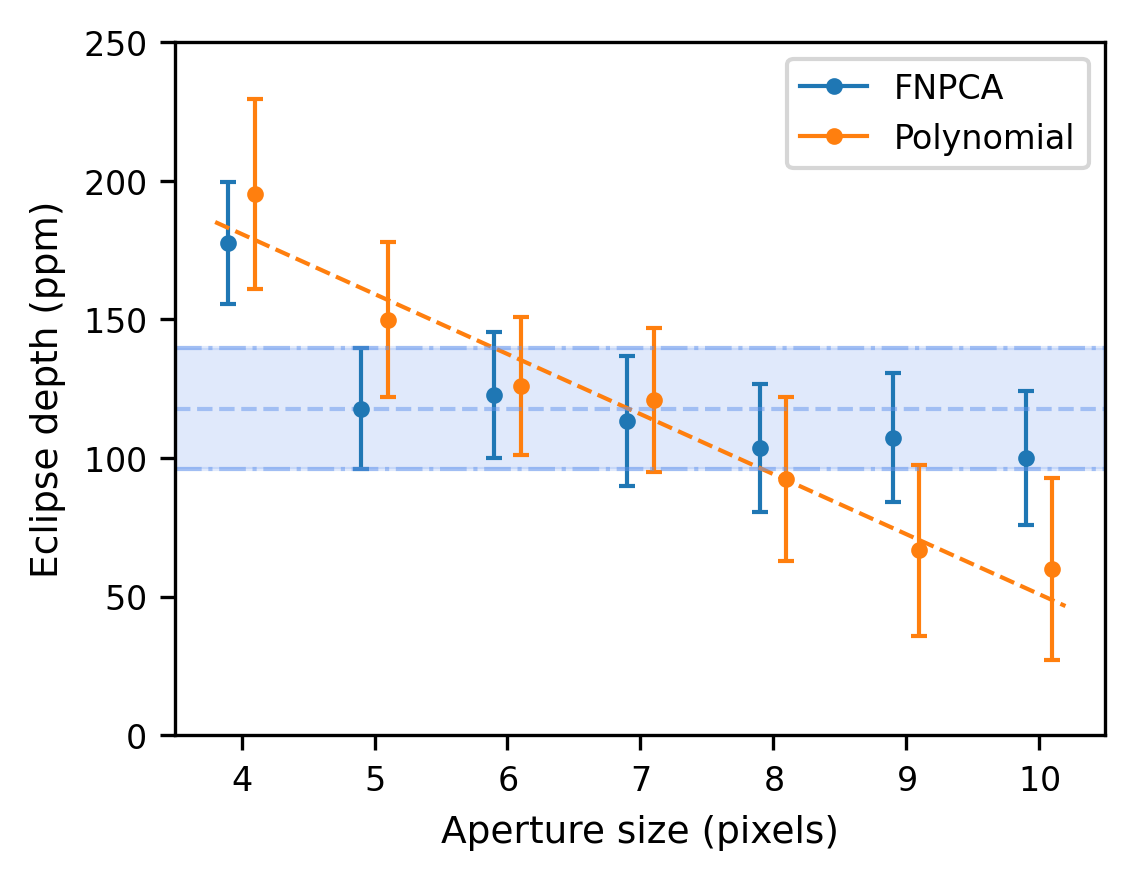

In [11]:
plt.figure(figsize=single_column)

for fit in fits:
	radius = fit.config['aperture_radius']
	depth = fit.results['fp']*1e6
	t_sec = fit.results['t_sec_offset']

	plt.errorbar([radius - 0.1], [depth.nominal_value], [depth.std_dev], marker='.', color='C0', capsize=2)

for fit in linear_fits:
	radius = fit.config['aperture_radius']
	depth = fit.results['fp']*1e6
	t_sec = fit.results['t_sec_offset']

	#plt.errorbar([radius], [depth.nominal_value], [depth.std_dev], marker='.', color='C1', capsize=2)

x = []
y = []

for fit in polynomial_fits:
	radius = fit.config['aperture_radius']
	depth = fit.results['fp']*1e6
	t_sec = fit.results['t_sec_offset']

	x.append(radius)
	y.append(depth.nominal_value)

	plt.errorbar([radius + 0.1], [depth.nominal_value], [depth.std_dev], marker='.', color='C1', capsize=2)

slope, intercept = np.polyfit(x, y, 1)
x = np.linspace(4-0.2, 10+0.2, 10)
plt.plot(x, slope * x + intercept, color='C1', linestyle='--')

#plt.errorbar([], [], marker='.', color='C1', label='Linear', capsize=2)
plt.errorbar([], [], marker='.', color='C0', label='FNPCA', capsize=2)
plt.errorbar([], [], marker='.', color='C1', label='Polynomial', capsize=2)

d5px = fits[2].results['fp']*1e6
d = d5px.nominal_value
derr = d5px.std_dev

plt.axhspan(d - derr, d + derr, alpha=0.2, color='cornflowerblue')
plt.axhline(d, linestyle='--', color='cornflowerblue', alpha=0.5)
plt.axhline(d - derr, linestyle='-.', color='cornflowerblue', alpha=0.5)
plt.axhline(d + derr, linestyle='-.', color='cornflowerblue', alpha=0.5)

plt.xlim([3.5, 10.5])
plt.ylim([0, 250])
plt.xlabel("Aperture size (pixels)")
plt.ylabel("Eclipse depth (ppm)")
plt.legend()
plt.savefig("figures/aperture_size.png", bbox_inches='tight')
plt.savefig("figures/aperture_size.pdf", bbox_inches='tight')

Text(0, 0.5, 'Eclipse time relative to 0.5 phase (min)')

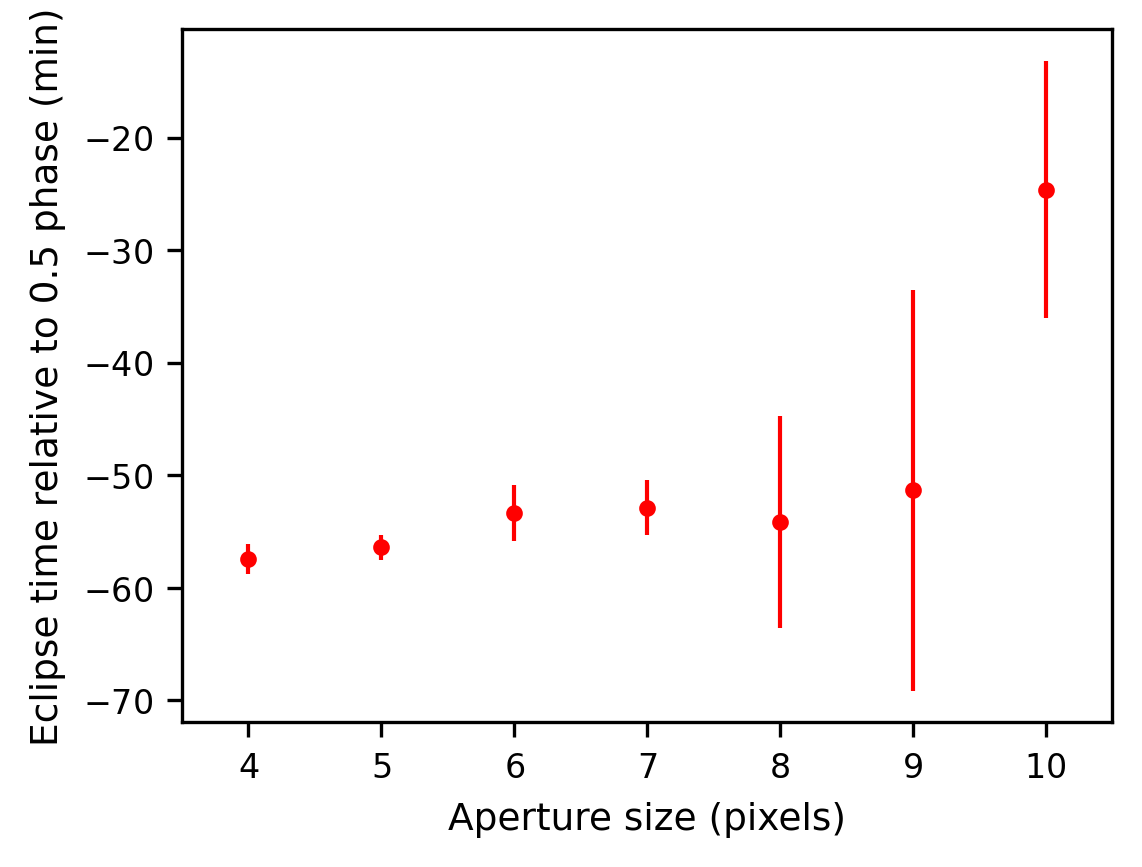

In [4]:
plt.figure(figsize=single_column)

for fit in polynomial_fits:
	radius = fit.config['aperture_radius']
	depth = fit.results['fp']*1e6
	t_sec = fit.results['t_sec_offset']*24*60

	plt.errorbar([radius], [t_sec.nominal_value], [t_sec.std_dev], marker='.', color='red')

plt.xlim([3.5, 10.5])
plt.xlabel("Aperture size (pixels)")
plt.ylabel("Eclipse time relative to 0.5 phase (min)")

(3.5, 10.5)

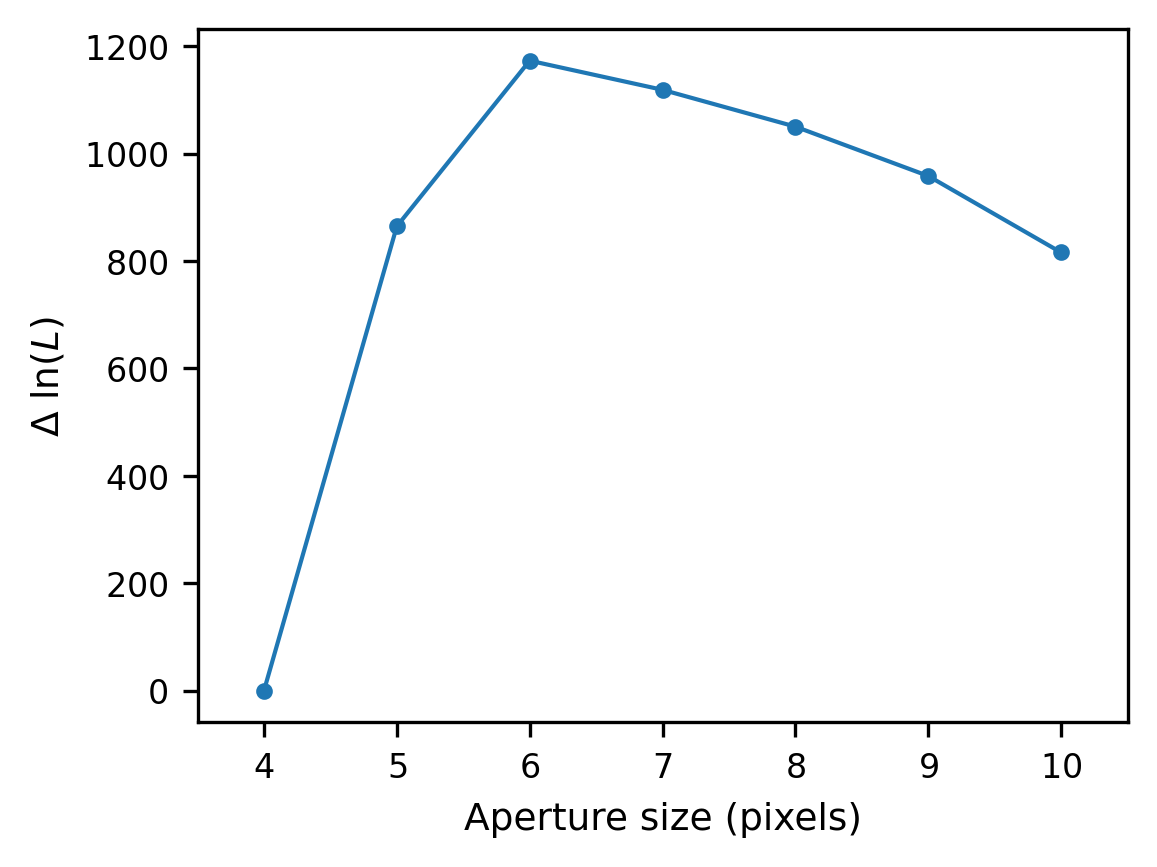

In [5]:
plt.figure(figsize=single_column)

radius = np.array([fit.config['aperture_radius'] for fit in polynomial_fits])
bics = np.array([fit.final_log_likelihood for fit in polynomial_fits])
s = np.argsort(radius)
radius = radius[s]
bics = bics[s]

plt.plot(radius, bics - np.min(bics), marker='.')
plt.xlabel("Aperture size (pixels)")
plt.ylabel(r"$\Delta$ ln($L$)")
plt.xlim([3.5, 10.5])

In [6]:
def make_latex_table(data, headers):
	data = np.array(data)
	lines = []
	lines.append(r"\begin{table}[h]")
	lines.append(r"    \centering")
	lines.append(r"        \begin{tabular}{cccc}")
	lines.append(r"        \hline")
	lines.append(f"        {' & '.join(headers)} \\\\")
	lines.append(r"        \hline")
	
	for row in data.T:
		lines.append(f"        {' & '.join(str(x) for x in row)} \\\\")
	
	lines.append(r"        \hline")
	lines.append(r"    \end{tabular}")
	lines.append(r"\end{table}")
	
	return "\n".join(lines)

headers = ["Radius (px)", "$f_p/f_\star$ (ppm)", "$\Delta t_{sec}$ (hrs)", "$\Delta$ log likelihood"]
radius = np.array([fit.config['aperture_radius'] for fit in fits])
bics = np.array([fit.final_log_likelihood for fit in fits])
linear_bics = np.array([fit.final_log_likelihood for fit in linear_fits])
depths = np.array([fit.results['fp']*1e6 for fit in fits])
timings = np.array([fit.results['t_sec_offset']*24*60 for fit in fits])
yerr = np.array([fit.results['y_err'].nominal_value*1e6 for fit in fits])
print(yerr)

s = np.argsort(radius)
radius = radius[s]
bics = bics[s]
depths = depths[s]
timings = timings[s]

# Format
depths = [f"${d.nominal_value:.0f} \pm {d.std_dev:.0f}$" for d in depths]
timings = [f"${d.nominal_value:.0f} \pm {d.std_dev:.1f}$" for d in timings]
bics = bics - np.max(bics)
bics = [f"{b:.0f}" for b in bics]

print(make_latex_table([radius, depths, timings, bics], headers))

[397.34749018 400.55361038 374.27611506 380.86147164 386.54991636
 389.61722041 390.09150641]
\begin{table}[h]
    \centering
        \begin{tabular}{cccc}
        \hline
        Radius (px) & $f_p/f_\star$ (ppm) & $\Delta t_{sec}$ (hrs) & $\Delta$ log likelihood \\
        \hline
        4 & $177 \pm 22$ & $-56 \pm 0.6$ & -165 \\
        5 & $118 \pm 22$ & $-54 \pm 2.4$ & 0 \\
        6 & $123 \pm 23$ & $-53 \pm 2.3$ & -51 \\
        7 & $113 \pm 23$ & $-53 \pm 2.3$ & -95 \\
        8 & $104 \pm 23$ & $-56 \pm 2.7$ & -107 \\
        9 & $107 \pm 23$ & $-56 \pm 2.5$ & -103 \\
        10 & $100 \pm 24$ & $-55 \pm 3.4$ & -147 \\
        \hline
    \end{tabular}
\end{table}


In [7]:
def calc_BIC(fit):
	k = sum(1 for x in fit.results.values() if x.std_dev != 0)
	n = len(fit.time)
	L = fit.final_log_likelihood
	print(k, n, L)
	return -2 * L + k * np.log(n)

def make_table(main_fits, comparison_fits):
	radius = np.array([fit.config['aperture_radius'] for fit in main_fits])
	bics = np.array([calc_BIC(fit) for fit in main_fits])
	comparison_bics = np.array([calc_BIC(fit) for fit in comparison_fits])
	depths = np.array([fit.results['fp']*1e6 for fit in main_fits])
	timings = np.array([fit.results['t_sec_offset']*24*60 for fit in main_fits])
	yerr = np.array([fit.results['y_err'].nominal_value*1e6 for fit in main_fits]) / 2
	
	s = np.argsort(radius)
	radius = radius[s]
	bics = bics[s]
	depths = depths[s]
	timings = timings[s]
	
	print(np.max(np.concatenate((bics, comparison_bics))))
	
	# Format
	depths = [f"${d.nominal_value:.0f} \pm {d.std_dev:.0f}$" for d in depths]
	timings = [f"${d.nominal_value:.0f} \pm {d.std_dev:.1f}$" for d in timings]
	bics = bics - np.min(np.concatenate((bics, fnpca_bics)))
	bics = [f"{b:.0f}" for b in bics]
	
	print(make_latex_table([radius, depths, timings, bics], headers))

In [8]:
make_table(polynomial_fits, fits)

25 3059 19327.44269873571
25 3060 18511.632986870227
25 3054 19376.071760739702
25 3054 19684.536534871513
25 3054 19630.248498880283
25 3056 19561.69436246772
25 3057 19469.825548079127
42 3059 19633.789209774317
42 3060 19616.414838596073
42 3054 19780.91984858458
42 3054 19730.102518704807
42 3054 19685.427814084112
42 3056 19674.26313977161
42 3057 19677.70981777568
-36822.61171886679


NameError: name 'fnpca_bics' is not defined

In [ ]:
make_table(fits, polynomial_fits)